In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [47]:
results_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')

In [ ]:
plt.scatter(results_df['bio_sim_150'],results_df['top_'])

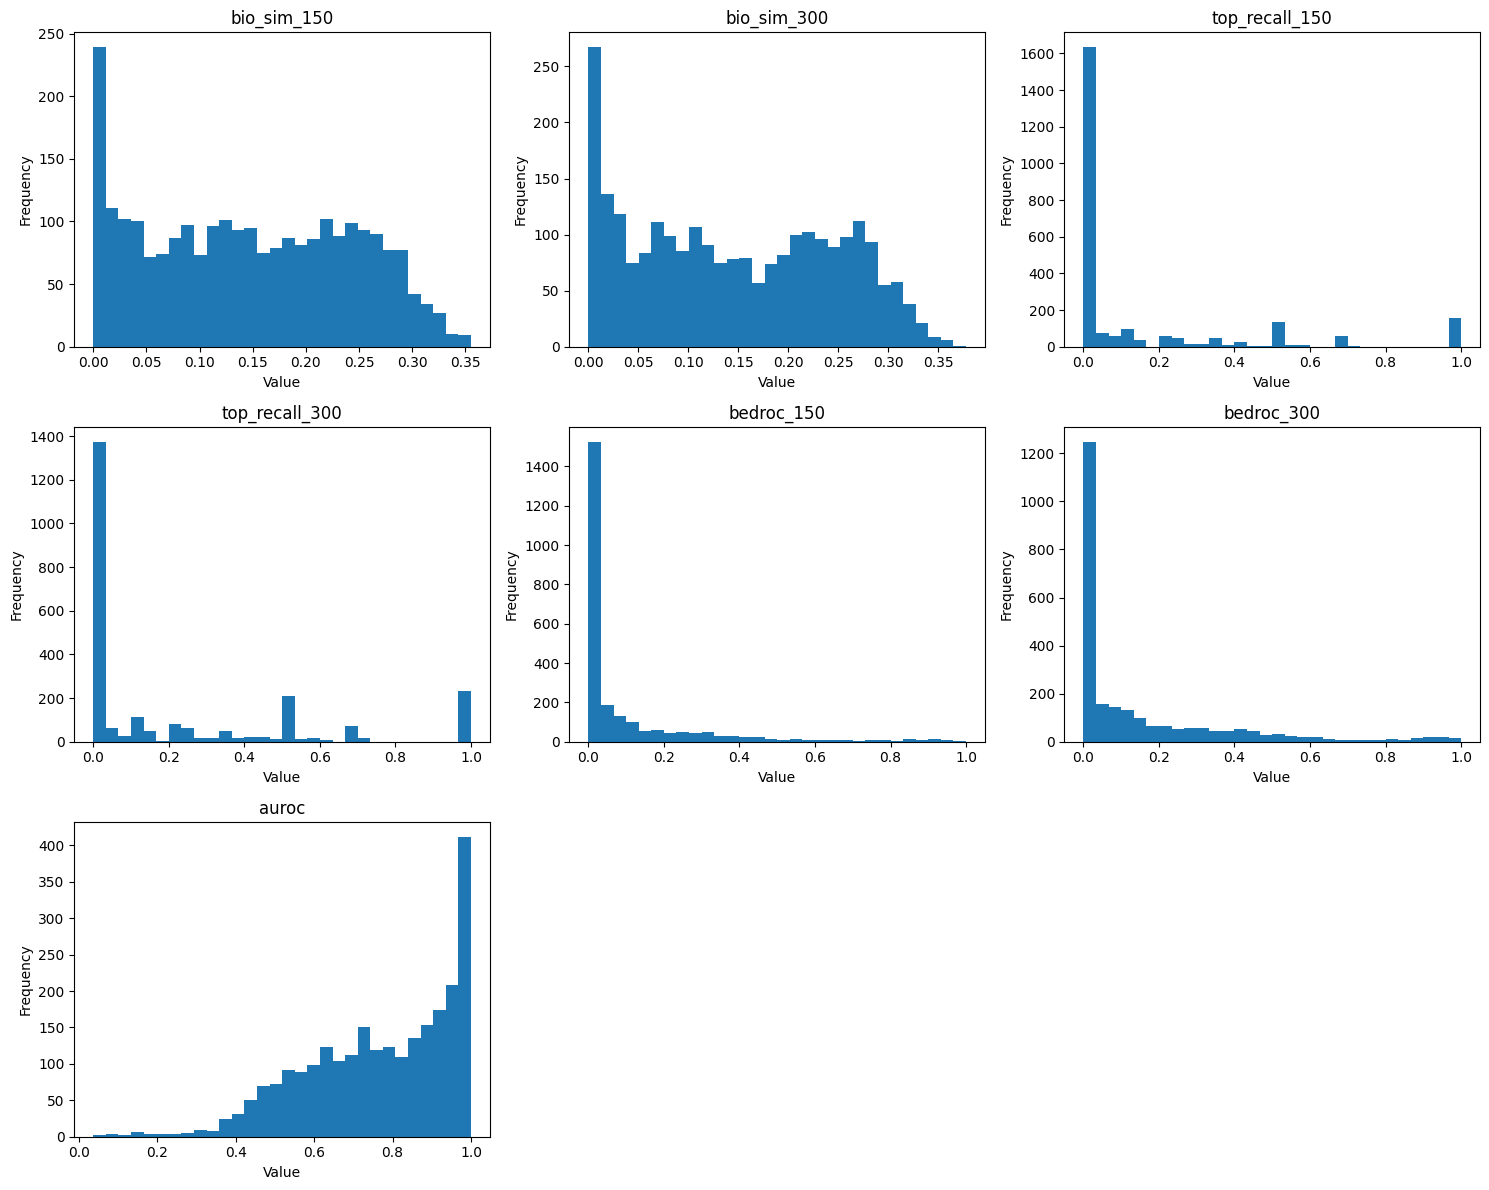

In [27]:
import matplotlib.pyplot as plt

all_m = [
    'bio_sim_150', 'bio_sim_300',
    'top_recall_150', 'top_recall_300',
    'bedroc_150', 'bedroc_300',
    'auroc'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, m in enumerate(all_m):
    axes[i].hist(results_df[m].dropna(), bins=30)
    axes[i].set_title(m)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for j in range(len(all_m), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def plot_bio_perf_pca(results_df, color_col=None):

    bio_cols = ['bio_sim_150', 'bio_sim_300']

    perf_col_groups = [
        ['top_recall_150', 'top_recall_300', 'bedroc_150', 'bedroc_300', 'auroc'],
        ['top_recall_150', 'top_recall_300', 'bedroc_150', 'bedroc_300'],
        ['top_recall_150', 'top_recall_300'],
        ['bedroc_150', 'bedroc_300']
    ]

    # Bio PCA
    bio_scaled = StandardScaler().fit_transform(results_df[bio_cols])
    bio_dim = PCA(n_components=1).fit_transform(bio_scaled).ravel()

    # Optional coloring
    if color_col is not None:

        color_values = results_df[color_col].astype(str)
        unique_values = color_values.unique()

        cmap = plt.cm.get_cmap('tab10', len(unique_values))

        color_dict = {
            val: cmap(i)
            for i, val in enumerate(unique_values)
        }

        point_colors = color_values.map(color_dict)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for ax, perf_cols in zip(axes, perf_col_groups):

        perf_scaled = StandardScaler().fit_transform(results_df[perf_cols])
        perf_dim = PCA(n_components=1).fit_transform(perf_scaled).ravel()

        if color_col is not None:

            ax.scatter(
                bio_dim,
                perf_dim,
                c=point_colors,
                alpha=0.7
            )

        else:

            ax.scatter(
                bio_dim,
                perf_dim,
                alpha=0.7
            )

        ax.set_title("Performance: " + ", ".join(perf_cols))
        ax.set_xlabel("Bio PCA dimension")
        ax.set_ylabel("Performance PCA dimension")

    # Add legend only if coloring is used
    if color_col is not None:

        handles = [
            plt.Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=color_dict[val],
                markersize=8,
                label=val
            )
            for val in unique_values
        ]


        fig.legend(
            handles=handles,
            title=color_col,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5)
        )

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

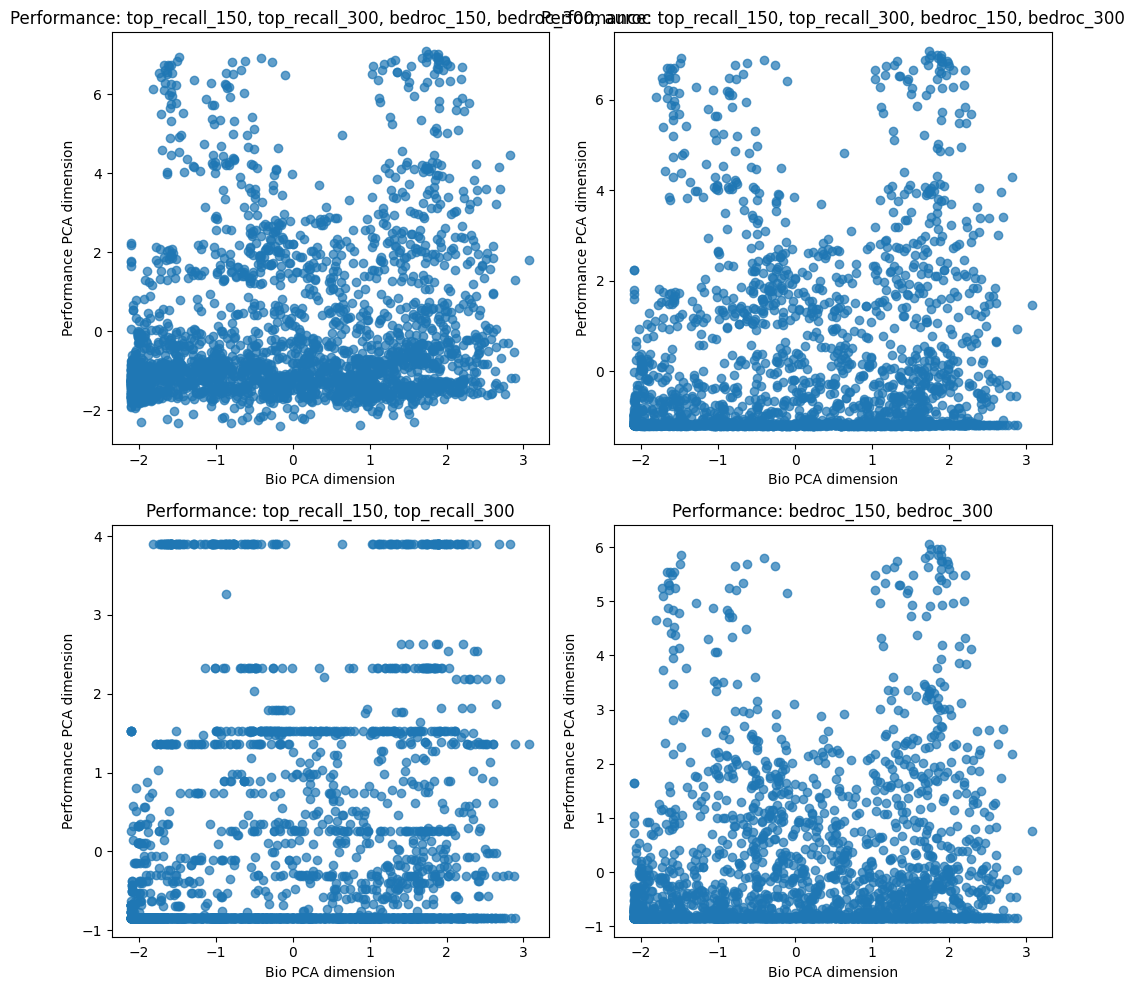

In [107]:
plot_bio_perf_pca(results_df)

/tmp/ipykernel_3992835/348612689.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_values))


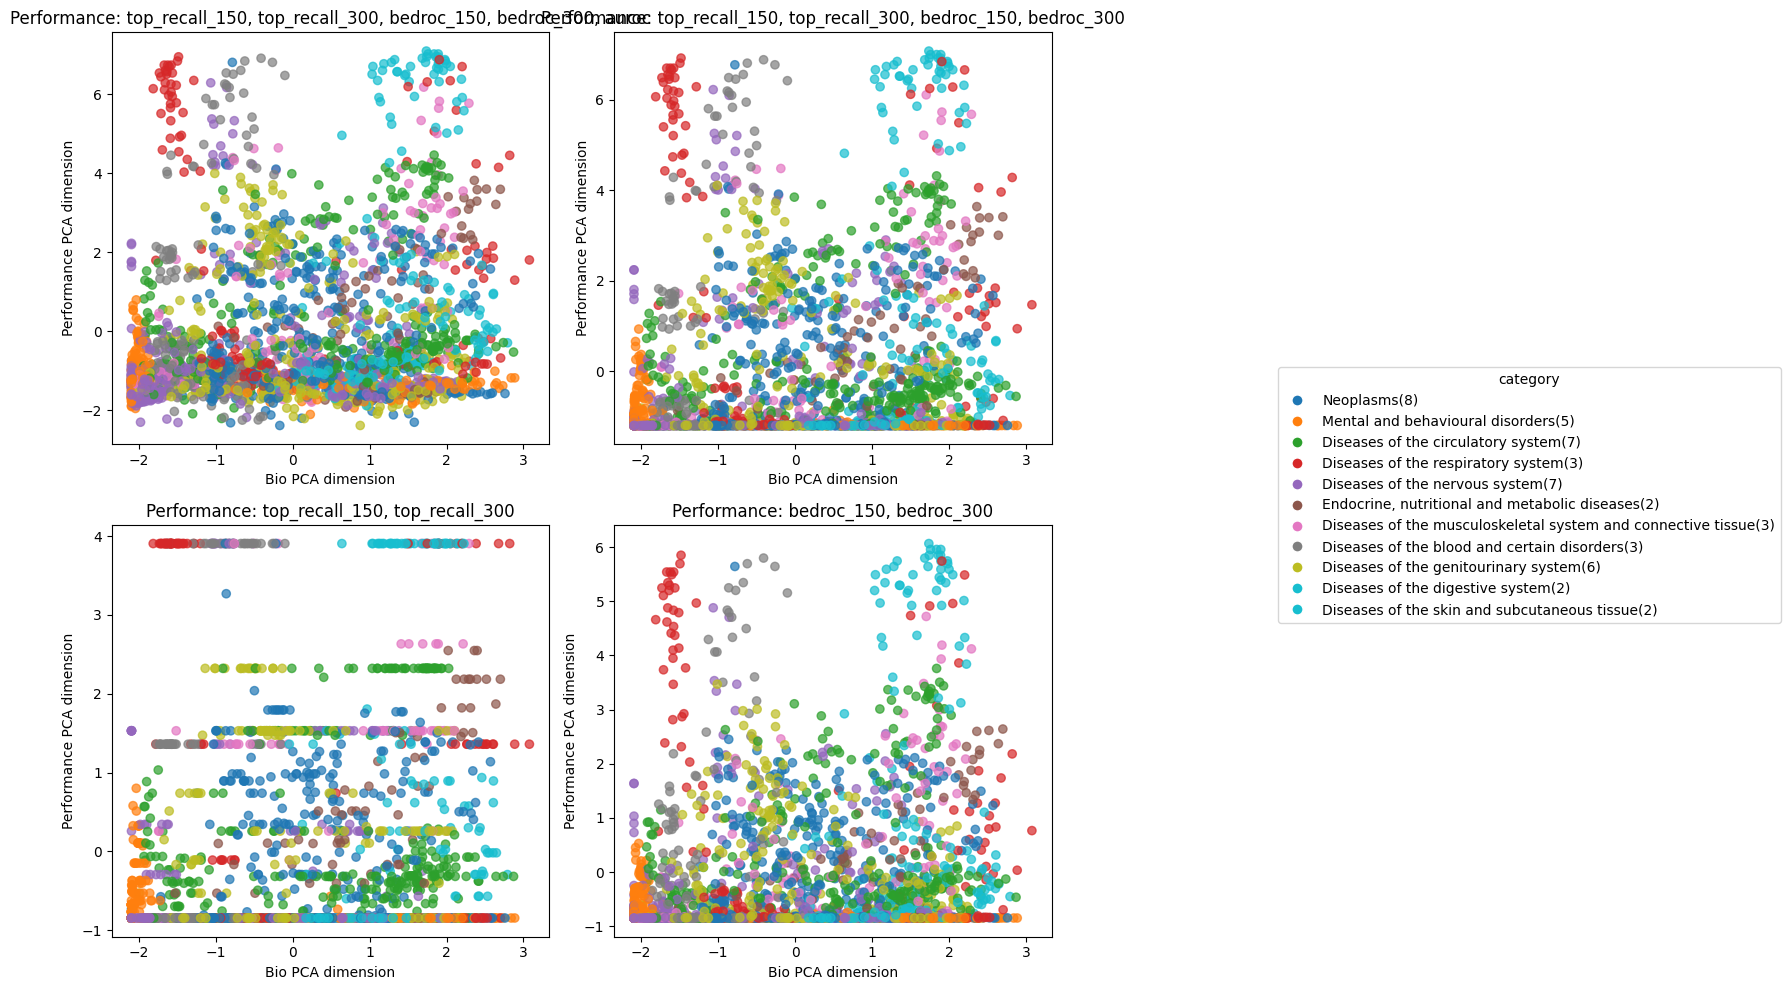

In [95]:
plot_bio_perf_pca(
    results_df,
    color_col='category'
)

In [98]:
metrics = [
    "bio_sim_300", "bio_sim_150",
    "top_recall_150", "top_recall_300",
    "bedroc_150", "bedroc_300",
    "auroc"
]

fusions = ['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_linear_fused', 'mid_geo_fused', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi', 'mid_fused', 'mid_fused_ppi']
features = ['ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df', 'literature_emb','seq_emb_esm', 'seq_emb_port']

recall_cols = ["top_recall_150", "top_recall_300"]
bedroc_cols = ["bedroc_150", "bedroc_300"]

show_cols = ["disease", "setting", "method",'category'] + metrics

out = []

filtered = (
    results_df[
        (results_df["setting"] == "df_gnn_occsvm_pred")
        & (results_df["method"].isin(fusions))
    ]
    .round(3)
)

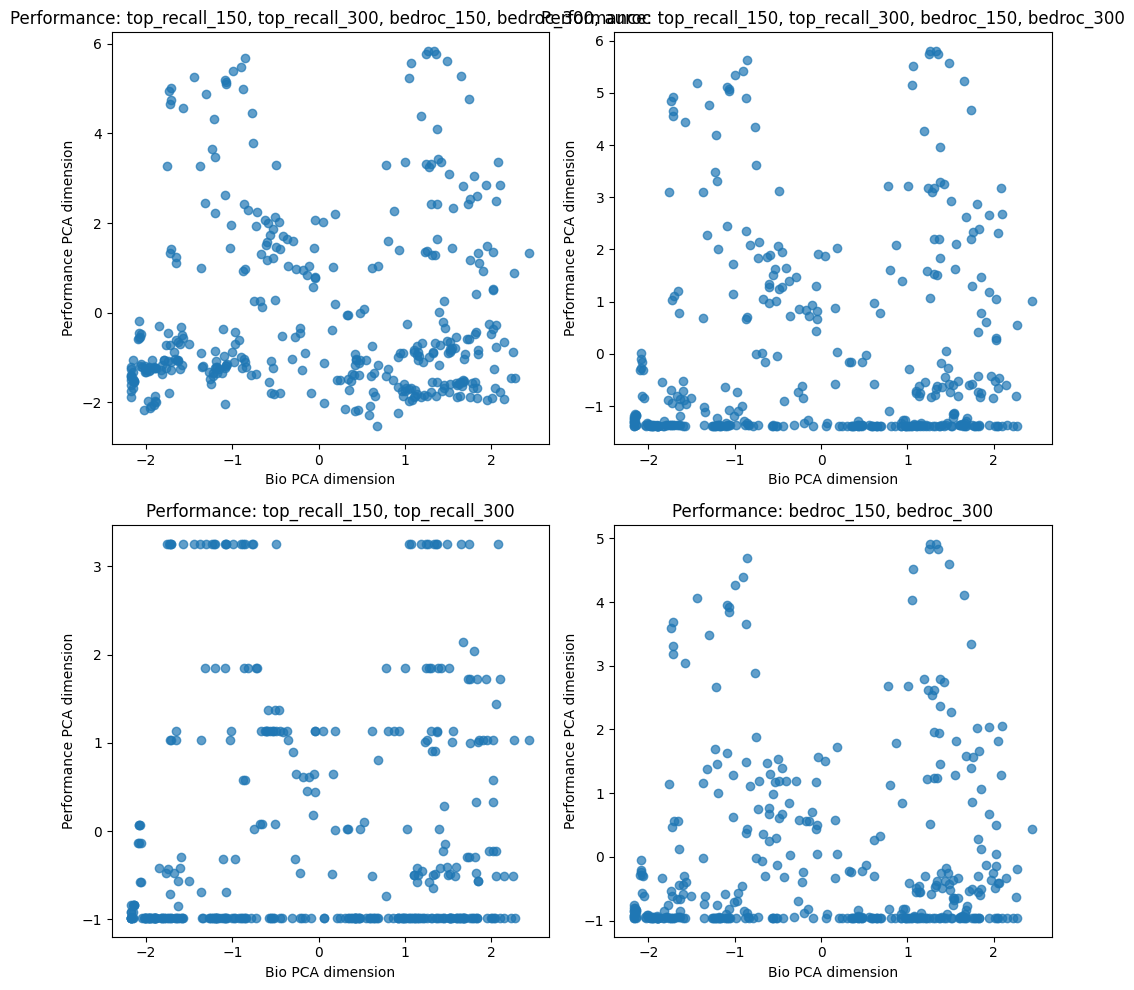

In [108]:
plot_bio_perf_pca(filtered)

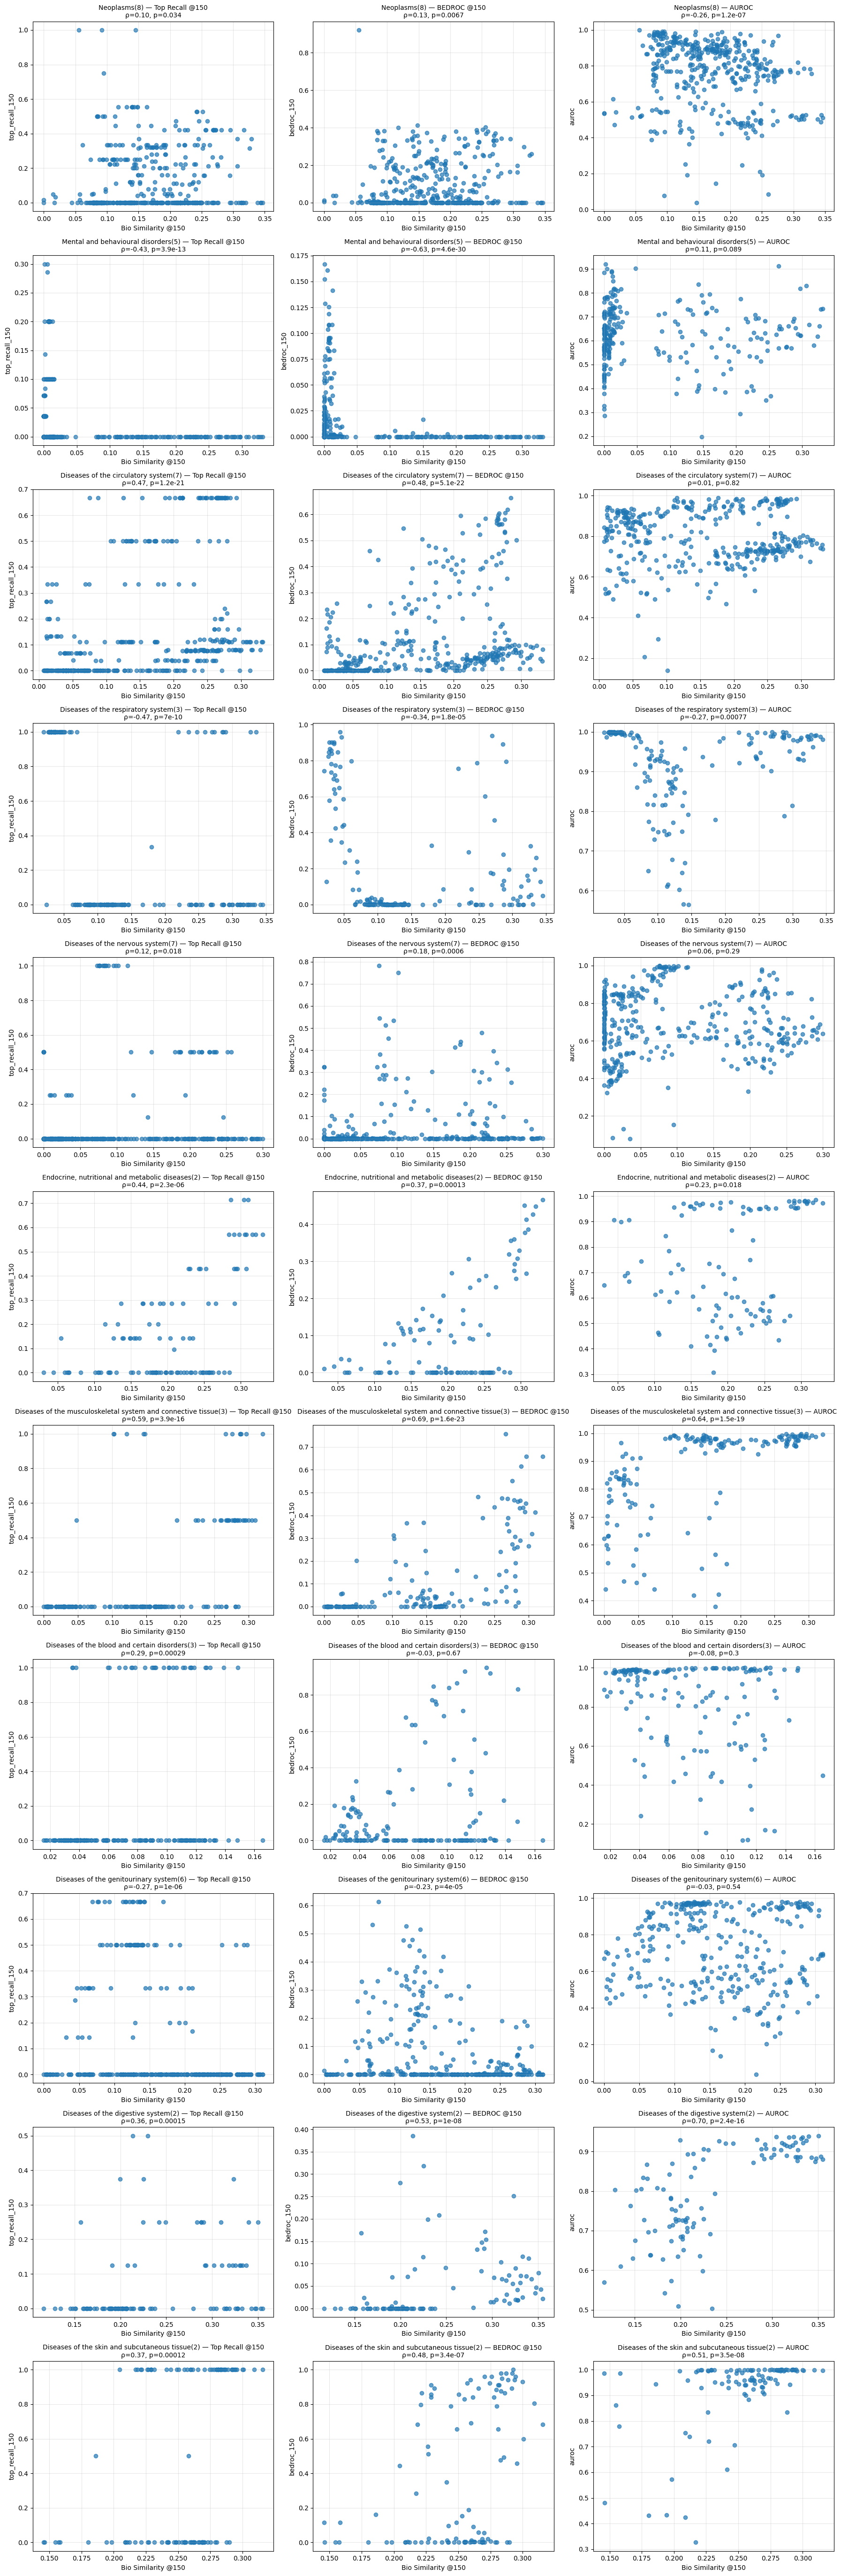

In [110]:
from scipy.stats import spearmanr

metrics = [
    ('top_recall_150', 'Top Recall @150'),
    ('bedroc_150', 'BEDROC @150'),
    ('auroc', 'AUROC')
]


categories = results_df['category'].unique()

fig, axes = plt.subplots(
    len(categories), 3,
    figsize=(18, 5 * len(categories)),  # wider
    squeeze=False
)

for row, category in enumerate(categories):

    subset = results_df[results_df['category'] == category]

    for col, (metric, title) in enumerate(metrics):

        ax = axes[row, col]

        ax.scatter(
            subset['bio_sim_150'],
            subset[metric],
            alpha=0.7
        )

        ax.set_xlabel('Bio Similarity @150')
        ax.set_ylabel(metric)
        rho, p = spearmanr(subset['bio_sim_150'], subset[metric])
        ax.set_title(f'{category} — {title}\nρ={rho:.2f}, p={p:.2g}', fontsize=10)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

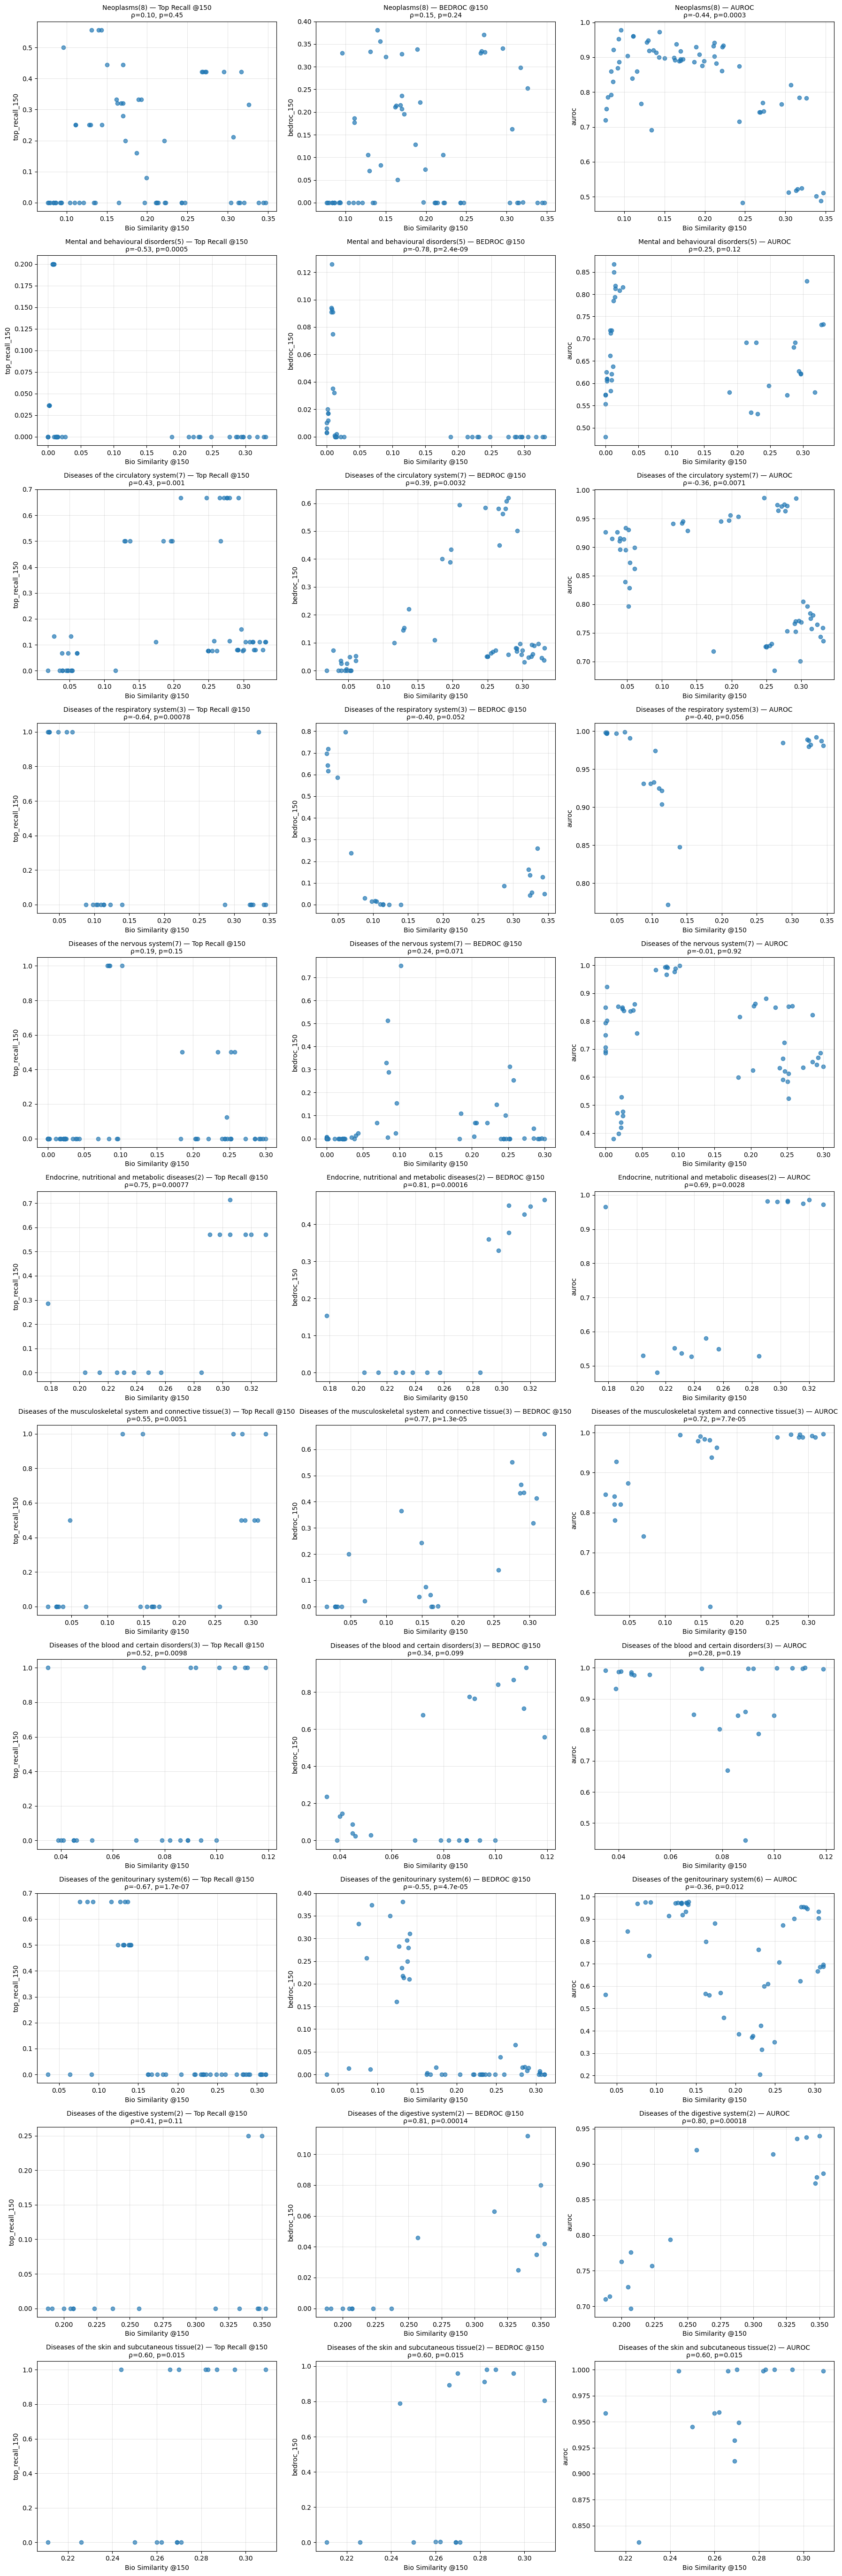

In [ ]:
from scipy.stats import spearmanr

metrics = [
    ('top_recall_150', 'Top Recall @150'),
    ('bedroc_150', 'BEDROC @150'),
    ('auroc', 'AUROC')
]


categories = filtered['category'].unique()

fig, axes = plt.subplots(
    len(categories), 3,
    figsize=(18, 5 * len(categories)),  # wider
    squeeze=False
)

for row, category in enumerate(categories):

    subset = filtered[filtered['category'] == category]

    for col, (metric, title) in enumerate(metrics):

        ax = axes[row, col]

        ax.scatter(
            subset['bio_sim_150'],
            subset[metric],
            alpha=0.7
        )

        ax.set_xlabel('Bio Similarity @150')
        ax.set_ylabel(metric)
        rho, p = spearmanr(subset['bio_sim_150'], subset[metric])
        ax.set_title(f'{category} — {title}\nρ={rho:.2f}, p={p:.2g}', fontsize=10)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import spearmanr, pearsonr

results = []

# stratified = 'category'

stratified = 'disease'

for category in filtered[stratified].unique():
    subset = filtered[filtered[stratified] == category]
    n = len(subset)
    
    # Need at least 3 points for a meaningful correlation
    if n < 3:
        results.append({
            'disease': category,
            'n': n,
            'spearman_rho': None,
            'spearman_p': None,
            'pearson_r': None,
            'pearson_p': None,
        })
        continue
    
    rho, p_spearman = spearmanr(subset['bio_sim_150'], subset['bedroc_150'])
    r, p_pearson = pearsonr(subset['bio_sim_150'], subset['bedroc_150'])
    
    results.append({
        'disease': category,
        'n': n,
        'spearman_rho': rho,
        'spearman_p': p_spearman,
        'pearson_r': r,
        'pearson_p': p_pearson,
    })

corr_table = pd.DataFrame(results)

# Sort by strongest absolute Spearman correlation
corr_table = corr_table.sort_values(
    by='spearman_rho',
    key=lambda s: s.abs(),
    ascending=False,
    na_position='last'
).reset_index(drop=True)

# Add a significance flag for quick scanning
def sig_label(p):
    if p is None or pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return 'ns'

corr_table['sig'] = corr_table['spearman_p'].apply(sig_label)

# Round for readability
corr_table_display = corr_table.copy()
for col in ['spearman_rho', 'spearman_p', 'pearson_r', 'pearson_p']:
    corr_table_display[col] = corr_table_display[col].round(4)

/tmp/ipykernel_3992835/2008253040.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_spearman = spearmanr(subset['bio_sim_150'], subset['bedroc_150'])
/tmp/ipykernel_3992835/2008253040.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p_pearson = pearsonr(subset['bio_sim_150'], subset['bedroc_150'])


In [133]:
corr_table_display

,disease,n,spearman_rho,spearman_p,pearson_r,pearson_p,sig
0,ICD10_I63,8,0.9762,0.0000,0.9111,0.0016,***
1,ICD10_C81,8,-0.9701,0.0001,-0.8671,0.0053,***
2,ICD10_J62,8,-0.9200,0.0012,-0.8303,0.0107,**
3,ICD10_E11,8,0.8743,0.0045,0.9507,0.0003,**
4,ICD10_C16,8,-0.8503,0.0075,-0.8666,0.0054,**
5,ICD10_G43,8,0.7958,0.0182,0.7576,0.0294,*
6,ICD10_M34,8,-0.7785,0.0229,-0.8762,0.0043,*
7,ICD10_F01,8,0.7655,0.0268,0.7606,0.0284,*
8,ICD10_F72,8,-0.7643,0.0272,-0.7087,0.0491,*
9,ICD10_M41,8,0.7370,0.0370,0.3768,0.3575,*


In [132]:
corr_table_display[corr_table_display['sig'].isin(['*','**','***'])]

,disease,n,spearman_rho,spearman_p,pearson_r,pearson_p,sig
0,ICD10_I63,8,0.9762,0.0000,0.9111,0.0016,***
1,ICD10_C81,8,-0.9701,0.0001,-0.8671,0.0053,***
2,ICD10_J62,8,-0.9200,0.0012,-0.8303,0.0107,**
3,ICD10_E11,8,0.8743,0.0045,0.9507,0.0003,**
4,ICD10_C16,8,-0.8503,0.0075,-0.8666,0.0054,**
5,ICD10_G43,8,0.7958,0.0182,0.7576,0.0294,*
6,ICD10_M34,8,-0.7785,0.0229,-0.8762,0.0043,*
7,ICD10_F01,8,0.7655,0.0268,0.7606,0.0284,*
8,ICD10_F72,8,-0.7643,0.0272,-0.7087,0.0491,*
9,ICD10_M41,8,0.7370,0.0370,0.3768,0.3575,*


In [ ]:
filtered_bedroc = filtered[
    (filtered[bedroc_cols] != 0).all(axis=1)
]

for disease, g in filtered_bedroc.groupby("disease"):

    # group rows with identical recall@k
    for _, sub in g.groupby(recall_cols, dropna=False):

        # need at least 2 rows to compare
        if len(sub) < 2:
            continue

        # BEDROC can distinguish them
        bedroc_differs = (
            sub[bedroc_cols]
            .drop_duplicates()
            .shape[0] > 1
        )

        if bedroc_differs:
            out.append(sub[show_cols])

recall_same_bedroc_diff = (
    pd.concat(out)
    .sort_values([
        "disease",
        "top_recall_150",
        "top_recall_300",
        "bedroc_150",
        "bedroc_300"
    ])
    .reset_index(drop=True)
)

recall_same_bedroc_diff

,disease,setting,method,category,bio_sim_300,bio_sim_150,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
0,ICD10_C16,df_gnn_occsvm_pred,mid_geo_fused_ppi,Neoplasms(8),0.147,0.163,0.320,0.440,0.214,0.304,0.892
1,ICD10_C16,df_gnn_occsvm_pred,late_fused_ppi,Neoplasms(8),0.151,0.170,0.320,0.440,0.236,0.329,0.895
2,ICD10_C18,df_gnn_occsvm_pred,mid_geo_fused,Neoplasms(8),0.135,0.162,0.333,0.444,0.211,0.309,0.898
3,ICD10_C18,df_gnn_occsvm_pred,early_fused,Neoplasms(8),0.170,0.193,0.333,0.444,0.222,0.300,0.908
4,ICD10_C18,df_gnn_occsvm_pred,late_fused,Neoplasms(8),0.139,0.189,0.333,0.444,0.338,0.379,0.929
...,...,...,...,...,...,...,...,...,...,...,...
182,ICD10_N97,df_gnn_occsvm_pred,late_fused_ppi,Diseases of the genitourinary system(6),0.113,0.131,0.500,0.500,0.235,0.349,0.970
183,ICD10_N97,df_gnn_occsvm_pred,early_fused,Diseases of the genitourinary system(6),0.143,0.138,0.500,0.500,0.250,0.361,0.972
184,ICD10_N97,df_gnn_occsvm_pred,late_fused,Diseases of the genitourinary system(6),0.111,0.139,0.500,0.500,0.280,0.379,0.970
185,ICD10_N97,df_gnn_occsvm_pred,mid_linear_fused,Diseases of the genitourinary system(6),0.114,0.141,0.500,0.500,0.311,0.409,0.977


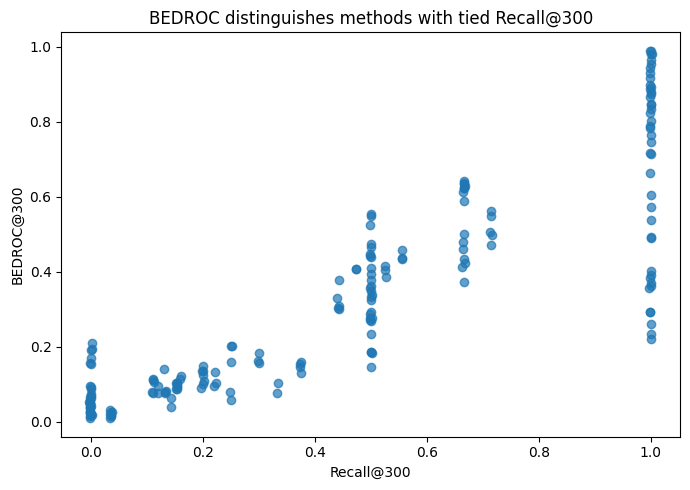

In [124]:
plot_df = recall_same_bedroc_diff.copy()

# jitter recall slightly so overlapping points become visible
x = plot_df["top_recall_300"] + np.random.normal(0, 0.001, len(plot_df))

plt.figure(figsize=(7, 5))

plt.scatter(
    x,
    plot_df["bedroc_300"],
    alpha=0.7
)

plt.xlabel("Recall@300")
plt.ylabel("BEDROC@300")
plt.title("BEDROC distinguishes methods with tied Recall@300")

plt.tight_layout()
plt.show()

In [83]:
recall_same_bedroc_diff['disease'].value_counts()

disease
ICD10_F72    8
ICD10_L20    8
ICD10_D66    8
ICD10_G40    8
ICD10_G10    8
ICD10_I70    8
ICD10_N97    8
ICD10_I42    8
ICD10_I63    7
ICD10_F01    7
ICD10_I50    7
ICD10_N04    7
ICD10_J80    7
ICD10_N18    6
ICD10_I25    6
ICD10_D57    6
ICD10_C18    6
ICD10_J45    6
ICD10_M32    6
ICD10_L40    5
ICD10_J62    5
ICD10_M34    5
ICD10_C67    5
ICD10_C81    5
ICD10_E11    5
ICD10_K51    4
ICD10_I10    4
ICD10_G30    3
ICD10_G91    3
ICD10_C16    2
ICD10_F90    2
ICD10_G43    2
ICD10_N46    2
Name: count, dtype: int64

In [84]:
recall_same_bedroc_diff['category'].value_counts()

category
Diseases of the circulatory system(7)                              40
Diseases of the nervous system(7)                                  24
Diseases of the genitourinary system(6)                            23
Neoplasms(8)                                                       18
Diseases of the respiratory system(3)                              18
Mental and behavioural disorders(5)                                17
Diseases of the blood and certain disorders(3)                     14
Diseases of the skin and subcutaneous tissue(2)                    13
Diseases of the musculoskeletal system and connective tissue(3)    11
Endocrine, nutritional and metabolic diseases(2)                    5
Diseases of the digestive system(2)                                 4
Name: count, dtype: int64

In [86]:
early_cols = ["top_recall_150", "top_recall_300", "bedroc_150", "bedroc_300"]
bio_cols = ["bio_sim_150", "bio_sim_300"]

out = []  # important: reset here

filtered_biosim = filtered[
    (filtered[bio_cols] != 0).all(axis=1)
]

for disease, g in filtered_biosim.groupby("disease"):

    # optionally round first if display-level equality is intended
    g = g.copy()
    g[early_cols] = g[early_cols].round(3)

    for _, sub in g.groupby(early_cols, dropna=False):

        if len(sub) < 2:
            continue

        bio_differs = (
            sub[bio_cols]
            .drop_duplicates()
            .shape[0] > 1
        )

        if bio_differs:
            out.append(sub[show_cols])

early_same_bio_diff = (
    pd.concat(out)
    .sort_values([
        "disease",
        "top_recall_150",
        "top_recall_300",
        "bedroc_150",
        "bedroc_300"
    ])
    .reset_index(drop=True)
)

early_same_bio_diff

,disease,setting,method,category,bio_sim_300,bio_sim_150,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
0,ICD10_C23,df_gnn_occsvm_pred,early_fused_ppi,Neoplasms(8),0.070,0.084,0.0,0.0,0.0,0.0,0.860
1,ICD10_C23,df_gnn_occsvm_pred,late_fused_ppi,Neoplasms(8),0.071,0.084,0.0,0.0,0.0,0.0,0.792
2,ICD10_C23,df_gnn_occsvm_pred,mid_linear_fused,Neoplasms(8),0.065,0.077,0.0,0.0,0.0,0.0,0.719
3,ICD10_C23,df_gnn_occsvm_pred,mid_geo_fused,Neoplasms(8),0.071,0.086,0.0,0.0,0.0,0.0,0.830
4,ICD10_C23,df_gnn_occsvm_pred,mid_linear_fused_ppi,Neoplasms(8),0.068,0.080,0.0,0.0,0.0,0.0,0.785
...,...,...,...,...,...,...,...,...,...,...,...
116,ICD10_N80,df_gnn_occsvm_pred,late_fused_ppi,Diseases of the genitourinary system(6),0.195,0.233,0.0,0.0,0.0,0.0,0.317
117,ICD10_N80,df_gnn_occsvm_pred,mid_linear_fused,Diseases of the genitourinary system(6),0.181,0.204,0.0,0.0,0.0,0.0,0.385
118,ICD10_N80,df_gnn_occsvm_pred,mid_geo_fused,Diseases of the genitourinary system(6),0.186,0.222,0.0,0.0,0.0,0.0,0.378
119,ICD10_N80,df_gnn_occsvm_pred,mid_linear_fused_ppi,Diseases of the genitourinary system(6),0.183,0.221,0.0,0.0,0.0,0.0,0.371


In [87]:
early_same_bio_diff['disease'].value_counts()

disease
ICD10_G24    8
ICD10_G20    8
ICD10_F31    8
ICD10_F20    8
ICD10_E66    8
ICD10_N80    8
ICD10_C43    7
ICD10_C53    7
ICD10_D83    7
ICD10_K44    7
ICD10_C23    6
ICD10_I26    6
ICD10_C50    5
ICD10_N46    5
ICD10_N17    4
ICD10_F90    4
ICD10_L20    4
ICD10_M41    4
ICD10_G43    3
ICD10_G40    2
ICD10_I70    2
Name: count, dtype: int64

In [88]:
early_same_bio_diff['category'].value_counts()

category
Neoplasms(8)                                                       25
Diseases of the nervous system(7)                                  21
Mental and behavioural disorders(5)                                20
Diseases of the genitourinary system(6)                            17
Diseases of the circulatory system(7)                               8
Endocrine, nutritional and metabolic diseases(2)                    8
Diseases of the blood and certain disorders(3)                      7
Diseases of the digestive system(2)                                 7
Diseases of the skin and subcutaneous tissue(2)                     4
Diseases of the musculoskeletal system and connective tissue(3)     4
Name: count, dtype: int64

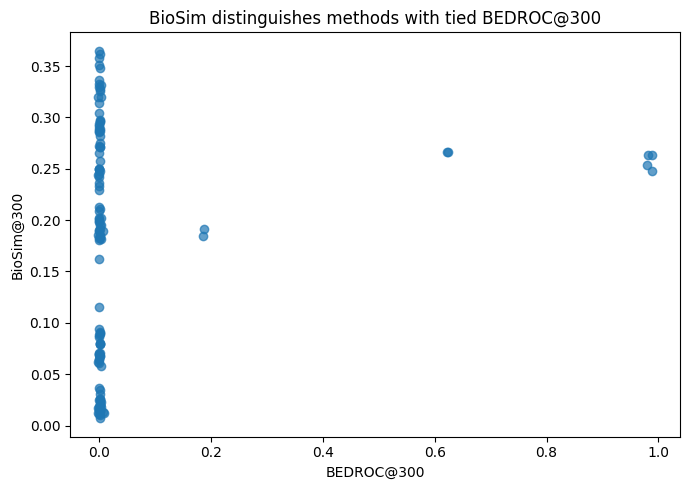

In [122]:
plot_df = early_same_bio_diff.copy()

# jitter recall slightly so overlapping points become visible
x = plot_df["bedroc_300"] + np.random.normal(0, 0.001, len(plot_df))

plt.figure(figsize=(7, 5))

plt.scatter(
    x,
    plot_df["bio_sim_300"],
    alpha=0.7
)

plt.xlabel("BEDROC@300")
plt.ylabel("BioSim@300")
plt.title("BioSim distinguishes methods with tied BEDROC@300")

plt.tight_layout()
plt.show()